<a href="https://colab.research.google.com/github/wesnasimone/IA025_Introducao_Aprendizado_Profundo/blob/main/(2026S2)_Exerc%C3%ADcio_Otimiza%C3%A7%C3%A3o_de_classifica%C3%A7%C3%A3o_de_imagens_com_redes_neurais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IA025 - Exercício: Otimização de classificação de imagens com redes *neurais*


Continue o exercício anterior, com objetivo de classificação de imagens utilizando os datasets MNIST e CIFAR-10.

Agora, você deve implementar o loop de treino sem utilizar alguns recursos do PyTorch Lightning e PyTorch.

*   Não use nn.CrossEntropyLoss - ou seja, implemente a ativação softmax + perda entropia cruzada utilizando operações sobre tensores PyTorch
*   Ainda não vamos usar redes convolucionais.
*   Tente melhorar a arquitetura com multiplas camadas, camada escondida e ativações não lineares como ReLU.
*   Experimente com variações de batch size, learning rate e outros hiperparâmetros.
*   No experimento com dataset CIFAR-10 use os mesmos parâmetros que deram certo ou melhor resultado no MNIST. Espera-se melhores resultados no CIFAR do que no exercício anterior, mesmo sem utilizarmos convoluções ainda.

Não esqueça de visualizar os dados para debugar se seus dataloaders/datasets estão funcionando, e plotar a loss durante treino e validação.

DESAFIO:
*   (médio) No loop de treino, otimizar a rede com estratégia do SGD sem usar o módulo optimizer do PyTorch. DICA: de posse do gradiente, é só atualizar os pesos iterando sobre .params do PyTorch.
*   (difícil) sem usar classe optimizer e .backward(). DICA: tente reproduzir as o método das diferenças finitas visto em classe.



## Treinamento de redes neurais com Pytorch: Grafo Computacional e Gradientes

Um dos principais fundamentos para que o PyTorch seja adequado para deep learning é a sua habilidade de calcular o gradiente automaticamente a partir da expressões definidas. Essa facilidade é implementada através do cálculo automático do gradiente e construção dinâmica do grafo computacional.

Vamos estudar como a otimização dos pesos funciona com um exemplo simples: otimizar um peso w para **duplicar** a entrada x.

Seja um exemplo simples de uma função de perda J dada pela Soma dos Erros ao Quadrado (SEQ - Sum of Squared Errors):
$$ J = \sum_i (x_i w - y_i)^2 $$
que pode ser reescrita como:
$$ \hat{y_i} = x_i w $$
$$ e_i = \hat{y_i} - y_i $$
$$ e2_i = e_i^2 $$
$$ J = \sum_i e2_i $$

As redes neurais são treinadas através da minimização de uma função de perda usando o método do gradiente descendente. Para ajustar o parâmetro $w$ precisamos calcular o gradiente $  \frac{ \partial J}{\partial w} $. Usando a
regra da cadeia podemos escrever:
$$ \frac{ \partial J}{\partial w} = \frac{ \partial J}{\partial e2_i} \frac{ \partial e2_i}{\partial e_i} \frac{ \partial e_i}{\partial \hat{y_i} } \frac{ \partial \hat{y_i}}{\partial w}$$

```
    y_pred = x * w
    e = y_pred - y
    e2 = e**2
    J = e2.sum()
```

As quatro expressões acima, para o cálculo do J podem ser representadas pelo grafo computacional visualizado a seguir: os círculos são as variáveis (tensores), os quadrados são as operações, os números em preto são os cálculos durante a execução das quatro expressões para calcular o J (forward, predict). O cálculo do gradiente, mostrado em vermelho, é calculado pela regra da cadeia, de trás para frente (backward).

<img src="https://raw.githubusercontent.com/robertoalotufo/files/master/figures/GrafoComputacional.png" width="600pt"/>

Para entender melhor o funcionamento do grafo computacional com os tensores, recomenda-se leitura em:

https://pytorch.org/docs/stable/notes/autograd.html

In [ ]:
import torch

In [ ]:
torch.__version__

'2.11.0+cpu'

**Tensor com atributo .requires_grad=True**

Quando um tensor possui o atributo `requires_grad` como verdadeiro, qualquer expressão que utilizar esse tensor irá construir um grafo computacional para permitir posteriormente, após calcular a função a ser derivada, poder usar a regra da cadeia e calcular o gradiente da função em termos dos tensores que possuem o atributo `requires_grad`.


In [ ]:
y = torch.arange(0, 8, 2).float()
y

tensor([0., 2., 4., 6.])

In [ ]:
x = torch.arange(0, 4).float()
x

tensor([0., 1., 2., 3.])

In [ ]:
w = torch.ones(1, requires_grad=True)
w

tensor([1.], requires_grad=True)

## Cálculo automático do gradiente da função perda J

Seja a expressão: $$ J = \sum_i ((x_i  w) - y_i)^2 $$

Queremos calcular a derivada de $J$ em relação a $w$.

## Forward pass

Durante a execução da expressão, o grafo computacional é criado. Compare os valores de cada parcela calculada com os valores em preto da figura ilustrativa do grafo computacional.

In [ ]:
# predict (forward)
y_pred = x * w; print('y_pred =', y_pred)

# cálculo da perda J: loss
e = y_pred - y; print('e =',e)
e2 = e.pow(2) ; print('e2 =', e2)
J = e2.sum()  ; print('J =', J)

y_pred = tensor([0., 1., 2., 3.], grad_fn=<MulBackward0>)
e = tensor([ 0., -1., -2., -3.], grad_fn=<SubBackward0>)
e2 = tensor([0., 1., 4., 9.], grad_fn=<PowBackward0>)
J = tensor(14., grad_fn=<SumBackward0>)


## Backward pass

O `backward()` varre o grafo computacional a partir da variável a ele associada (raiz) e calcula o gradiente para todos os tensores que possuem o atributo `requires_grad` como verdadeiro.
Observe que os tensores que tiverem o atributo `requires_grad` serão sempre folhas no grafo computacional.
O `backward()` destroi o grafo após sua execução. Esse comportamento é padrão no PyTorch.

A título ilustrativo, se quisermos depurar os gradientes dos nós que não são folhas no grafo computacional, precisamos primeiro invocar `retain_grad()` em cada um desses nós, como a seguir. Entretanto nos exemplos reais não há necessidade de verificar o gradiente desses nós.

In [ ]:
e2.retain_grad()
e.retain_grad()
y_pred.retain_grad()

E agora calculamos os gradientes com o `backward()`.

w.grad é o gradiente de J em relação a w.

In [ ]:
if w.grad: w.grad.zero_()
J.backward()
print(w.grad)

tensor([-28.])


Mostramos agora os gradientes que estão grafados em vermelho no grafo computacional:

In [ ]:
print(e2.grad)
print(e.grad)
print(y_pred.grad)

tensor([1., 1., 1., 1.])
tensor([ 0., -2., -4., -6.])
tensor([ 0., -2., -4., -6.])



Calcule o mesmo gradiente ilustrado no exemplo anterior usando a regra das diferenças finitas, de acordo com a equação a seguir, utilizando um valor de $\Delta w$ bem pequeno.

$$ \frac{\partial J}{\partial w} = \frac{J(w + \Delta w) - J(w - \Delta w)}{2 \Delta w} $$

In [ ]:
def J_func(w, x, y):
    # Função que calcula J
    y_pred = x * w
    e = y_pred - y
    e2 = e.pow(2)
    J = e2.sum()
    return J

# Calcule o gradiente usando a regra diferenças finitas
# Confira com o valor já calculado anteriormente
x = torch.arange(0, 4).float()
y = torch.arange(0, 8, 2).float()
w = torch.ones(1)

# Definir um valor pequeno para delta_w e calcular diferenças finitas
delta_w = 1e-2
J_plus_delta = J_func(w + delta_w, x, y)
J_minus_delta = J_func(w - delta_w, x, y)

grad = (J_plus_delta - J_minus_delta) / (2 * delta_w)
print('grad=', grad)

grad= tensor(-28.0000)


Minimizando $J$ pelo gradiente descendente

$$ w_{k+1} = w_k - \lambda \frac {\partial J}{\partial w} $$

Supondo que valor inicial ($k=0$) $w_0 = 1$, use learning rate $\lambda = 0.01$ para calcular o valor do novo $w_{20}$, ou seja, fazendo 20 atualizações de gradientes. Deve-se usar a função `J_func` criada no exercício anterior.

Confira se o valor do primeiro gradiente está de acordo com os valores já calculado acima

i = 0
J= tensor(14.)
grad = tensor(-27.9999)
w = tensor([1.2800])
i = 1
J= tensor(7.2576)
grad = tensor(-20.1607)
w = tensor([1.4816])
i = 2
J= tensor(3.7623)
grad = tensor(-14.5137)
w = tensor([1.6267])
i = 3
J= tensor(1.9505)
grad = tensor(-10.4505)
w = tensor([1.7312])
i = 4
J= tensor(1.0112)
grad = tensor(-7.5281)
w = tensor([1.8065])
i = 5
J= tensor(0.5240)
grad = tensor(-5.4196)
w = tensor([1.8607])
i = 6
J= tensor(0.2716)
grad = tensor(-3.9014)
w = tensor([1.8997])
i = 7
J= tensor(0.1407)
grad = tensor(-2.8086)
w = tensor([1.9278])
i = 8
J= tensor(0.0729)
grad = tensor(-2.0218)
w = tensor([1.9480])
i = 9
J= tensor(0.0378)
grad = tensor(-1.4555)
w = tensor([1.9626])
i = 10
J= tensor(0.0196)
grad = tensor(-1.0472)
w = tensor([1.9731])
i = 11
J= tensor(0.0102)
grad = tensor(-0.7540)
w = tensor([1.9806])
i = 12
J= tensor(0.0053)
grad = tensor(-0.5432)
w = tensor([1.9860])
i = 13
J= tensor(0.0027)
grad = tensor(-0.3910)
w = tensor([1.9900])
i = 14
J= tensor(0.0014)
grad = tensor(-0.2

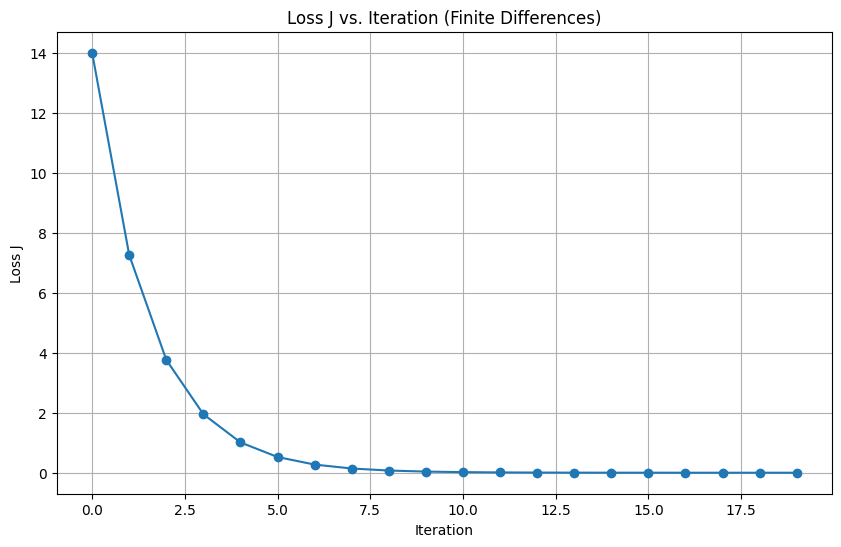

In [ ]:
import matplotlib.pyplot as plt

learning_rate = 0.01
iteracoes = 20

x = torch.arange(0, 4).float()
y = torch.arange(0, 8, 2).float()
w = torch.ones(1)

# Define delta_w for finite differences
delta_w = 1e-4

loss_history = []

for i in range(iteracoes):
    print('i =', i)
    J = J_func(w, x, y)
    loss_history.append(J.item())
    print('J=', J)

    # Calculando gradiente por diferenças finitas
    J_plus_delta = J_func(w + delta_w, x, y)
    J_minus_delta = J_func(w - delta_w, x, y)
    grad = (J_plus_delta - J_minus_delta) / (2 * delta_w)
    print('grad =',grad)

    # Atualizar w, técnica do SGD (stochastic gradient descent)
    w = w - learning_rate * grad
    print('w =', w)

# Plote o gráfico da loss J pela iteração i
plt.figure(figsize=(10, 6))
plt.plot(range(iteracoes), loss_history, marker='o')
plt.title('Loss J vs. Iteration (Finite Differences)')
plt.xlabel('Iteration')
plt.ylabel('Loss J')
plt.grid(True)
plt.show()

Repita a célula anterior mas usando agora o calculando o gradiente usando o método backward() do pytorch. Confira se o primeiro valor do gradiente está de acordo com os valores anteriores. Execute essa próxima célula duas vezes. Os valores devem ser iguais.


i = 0
J= tensor(14., grad_fn=<SumBackward0>)
grad = tensor([-28.])
w = tensor([1.2800], requires_grad=True)
i = 1
J= tensor(7.2576, grad_fn=<SumBackward0>)
grad = tensor([-20.1600])
w = tensor([1.4816], requires_grad=True)
i = 2
J= tensor(3.7623, grad_fn=<SumBackward0>)
grad = tensor([-14.5152])
w = tensor([1.6268], requires_grad=True)
i = 3
J= tensor(1.9504, grad_fn=<SumBackward0>)
grad = tensor([-10.4509])
w = tensor([1.7313], requires_grad=True)
i = 4
J= tensor(1.0111, grad_fn=<SumBackward0>)
grad = tensor([-7.5247])
w = tensor([1.8065], requires_grad=True)
i = 5
J= tensor(0.5241, grad_fn=<SumBackward0>)
grad = tensor([-5.4178])
w = tensor([1.8607], requires_grad=True)
i = 6
J= tensor(0.2717, grad_fn=<SumBackward0>)
grad = tensor([-3.9008])
w = tensor([1.8997], requires_grad=True)
i = 7
J= tensor(0.1409, grad_fn=<SumBackward0>)
grad = tensor([-2.8086])
w = tensor([1.9278], requires_grad=True)
i = 8
J= tensor(0.0730, grad_fn=<SumBackward0>)
grad = tensor([-2.0222])
w = tensor([1.9480

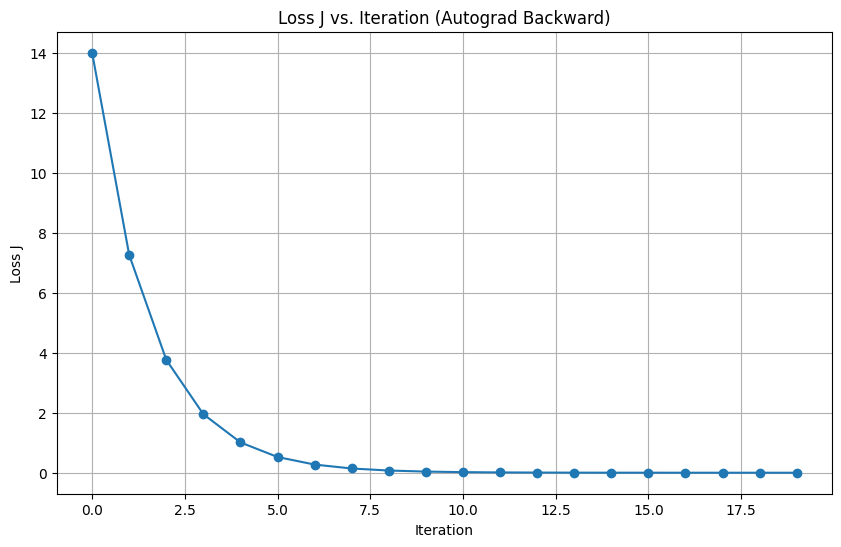

In [ ]:
import matplotlib.pyplot as plt

learning_rate = 0.01
iteracoes = 20

x = torch.arange(0, 4).float()
y = torch.arange(0, 8, 2).float()
w = torch.ones(1, requires_grad=True)

loss_history = []

for i in range(iteracoes):
    print('i =', i)

    # Zerar gradiente anterior
    if w.grad is not None:
        w.grad.zero_()

    J = J_func(w, x, y)
    loss_history.append(J.item()) # Guardar a perda
    print('J=', J)

    J.backward() # Computar gradientes com autograd do PyTorch
    grad = w.grad
    print('grad =',grad)

    # Atualização manual do w.
    with torch.no_grad():
        # Essa operação precisa de gradiente armazenado
        w -= learning_rate * grad
    print('w =', w)

# Plote aqui a loss pela iteração
plt.figure(figsize=(10, 6))
plt.plot(range(iteracoes), loss_history, marker='o')
plt.title('Loss J vs. Iteration (Autograd Backward)')
plt.xlabel('Iteration')
plt.ylabel('Loss J')
plt.grid(True)
plt.show()

## Pergunta 1)

Até agora trabalhamos com $w$ contendo apenas um parâmetro. Suponha agora que $w$ seja uma matriz com $N$ parâmetros e que o custo para executar $(x_i w - y_i)^2$ seja $O(N)$.
> a) Qual é o custo computacional para fazer uma única atualização (um passo de gradiente) dos parâmetros de $w$ usando o método das diferencas finitas?
>
> b) Qual é o custo computacional para fazer uma única atualização (um passo de gradiente) dos parâmetros de $w$ usando o método do backpropagation?



Resposta:

a) O(N^2), pois a função de custo (O(N)) terá que ser derivada/calculada N vezes conforme o tamanho de w. Assim, O(NxN).

b) O(N), pois diferente do caso anterior o backpropagation calcula o gradiente dos N pesos de uma única vez.

## Pergunta 2)

Qual o custo (entropia cruzada) esperado para um exemplo (uma amostra) no começo do treinamento de um classificador inicializado aleatoriamente?

A equação da entropia cruzada para cada exemplo é:
$$L = - \sum_{j=0}^{K-1} y_j \log p_j, $$
Onde:

- K é o número de classes;

- $y_j=1$ se $j$ é a classe do exemplo (ground-truth), 0 caso contrário. Ou seja, $y$ é um vetor one-hot;

- $p_j$ é a probabilidade predita pelo modelo para a classe $j$.

A resposta tem que ser em função de uma ou mais das seguintes variáveis:

- K = número de classes

- B = batch size

- D = dimensão de qualquer vetor do modelo

- LR = learning rate

**Resposta:**
O custo computacional do calculo da entropia cruzada para uma única amostra seria O(K), dado que as somas e multiplicações são feitas considerando cada classe. No entanto, ao se considerar o batch a iteração por K classes deve ser multiplicada pelo número de batches B resultando em uma complexidade de O(KxB).

# Exercício
O código abaixo já está pronto para treinar uma camada linear para classificação das imagens do MNIST.

## Coloque seu nome

In [ ]:
# TODO: imprima o seu nome completo
print(f'Wesna Simone Bulla de Araujo - RA: 225843')

Wesna Simone Bulla de Araujo - RA: 225843


In [ ]:
!pip install pytorch_lightning torchmetrics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 16.9 MB/s eta 0:00:00


## Exercício

Reutilize a sua implementação da camada linear, a versão matricial otimizada, e proponha uma arquitetura de rede neural (MyNeuralNetwork).

Sugestões:

* Múltiplas camadas (MLP)
* Ativação não-linear na camada escondida
* Testar Dropout

Além disso, implemente MyCrossEntropyLoss (ativação softmax + entropia cruzada) em vez de usar nn.CrossEntropyLoss.

In [ ]:
# NOVO: um dicionário de hiperparâmetros é uma forma de organizar parâmetros do seu experimento.
# Você pode adicionar mais parâmetros, experimente muda-los!
hyperparameters = {
    "batch_size": 32,
    "learning_rate": 0.0001,
    "hidden_size1": 128,  # tamanho da camada escondida, se usada
    "hidden_size2": 64,
    "hidden_size3": 32,
    "num_classes": 10,
    "dropout": 0.2
    # Qualquer parâmetro do código pode ser colocado aqui, parametrizando todo o experimento com um único dicionário
}

In [ ]:
import torch
import torch.nn as nn

class MyLinearLayer(torch.nn.Module):
    """
    Utilize sua implementação da camada linear do exercício anterior.
    Usar nn.Linear também é permitido.
    """
    def __init__(self, in_features, n_out, bias=True):
        super().__init__()
        self.in_features = in_features
        self.n_out = n_out
        self.bias = bias

        #foi necessario multiplicar os pesos por um valor pequeno para evitar que o gradiente ficasse muito grande
        self.weight = nn.Parameter(torch.randn((in_features, n_out), requires_grad=True)*0.1) #variavel treinavel durante o treinamento
        self.b = nn.Parameter(torch.randn((1, n_out), requires_grad=True))                    #variavel treinavel durante o treinamento


    def forward(self, input_tensor):
        # y = X.W + b
        multi = input_tensor @ self.weight

        if self.bias == True:
          y = multi + self.b
        else:
          y = multi

        return y

class MyNeuralNetwork(torch.nn.Module):
    """
    Crie uma rede neural com multiplas camadas.
    """
    def __init__(self, in_features, n_out, hparams, bias=True):
        super().__init__()
        self.hparams = hparams
        self.bias = bias

        self.layer1 = MyLinearLayer(in_features, self.hparams['hidden_size1'], bias=self.bias)
        self.layer2 = MyLinearLayer(self.hparams['hidden_size1'], self.hparams['hidden_size2'], bias=self.bias)
        self.layer3 = MyLinearLayer(self.hparams['hidden_size2'],  self.hparams['hidden_size3'], bias=self.bias)
        self.layer4 = MyLinearLayer(self.hparams['hidden_size3'], n_out, bias=self.bias)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(self.hparams['dropout'])

    def forward(self, input_tensor):
        x = self.layer1(input_tensor)
        x = self.relu(x)
        x = self.layer2(x)
        x = self.relu(x)
        x = self.layer3(x)
        x = self.dropout(x)
        x = self.layer4(x)

        return x


In [ ]:
import numpy as np

class MNIST(torch.utils.data.Dataset):
    """
    Reutilize sua implementação do exercício anterior
    """
    def __init__(self, normalize=False, train=False):
        super().__init__()
        from torchvision.datasets import MNIST

        self.base_dataset = MNIST(root='./data', train=train, download=True)
        self.normalize = normalize

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        """Retorna (image: np.ndarray, label: int).

        - Converta a imagem do MNIST para np.ndarray float.
        - Se self.normalize, aplique a normalização min-max para [0, 1] (Exercício 3.1)
        """
        image, label = self.base_dataset[idx]
        image = np.array(image, dtype=np.float32)
        if self.normalize:
            image = self.min_max(image)

        image = torch.from_numpy(image).float()
        imagem_1d = image.flatten()

        return imagem_1d, label, image

    def min_max(self, array):
        array = np.array(array)
        return (array - array.min()) / (array.max() - array.min())

In [ ]:
import pytorch_lightning as pl
from torch.utils.data import DataLoader
from torchmetrics import Accuracy

In [ ]:
class DataModule(pl.LightningDataModule):
    def __init__(self, hparams):
        super().__init__()

        # O PyTorch Lightning possui funções para facilitar o uso, log e recuperação de hiperparâmetros
        self.save_hyperparameters(hparams)

    def setup(self, stage=None):
        self.train = MNIST(train=True, normalize=True)
        self.val = MNIST(train=False, normalize=True)

    def train_dataloader(self):
        return DataLoader(self.train,
                          batch_size=self.hparams.batch_size,  # note o uso do hiperparâmetro configurável
                          shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val,
                          batch_size=self.hparams.batch_size,
                          shuffle=False)



# Inicialize o DataModule, Dataloader, e visualize se os dados que vão entrar na rede fazem sentido!

In [ ]:
datamodule = DataModule(hyperparameters)
datamodule.setup()

train_dataloader = datamodule.train_dataloader()
val_dataloader = datamodule.val_dataloader()

# TODO visualize o batch do dataloader
#visualiza o primeiro batch

primeiro_batch = next(iter(train_dataloader))
imagem_linearizada, label, imagem = primeiro_batch
print(f"Imagem Linearizada: {imagem_linearizada.shape} --- Label: {label.shape} --- Imagem Original: {imagem.shape}")
print("input max:", imagem_linearizada.abs().max())
print("input min:", imagem_linearizada.min())

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 455kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.06MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.59MB/s]


Imagem Linearizada: torch.Size([32, 784]) --- Label: torch.Size([32]) --- Imagem Original: torch.Size([32, 28, 28])
input max: tensor(1.)
input min: tensor(0.)


Label: 6


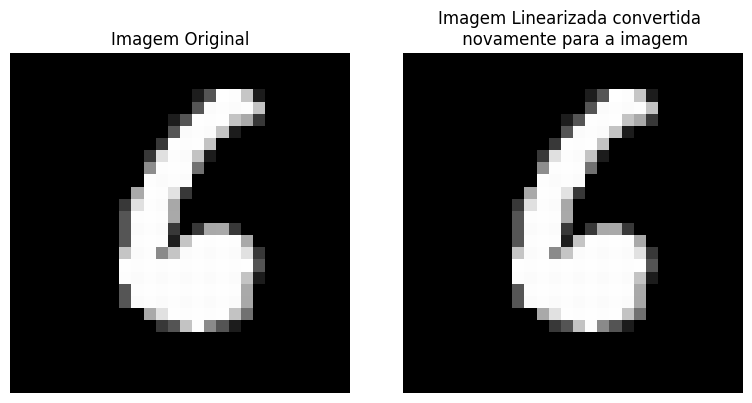

In [ ]:
#Plotar imagens MNIST
import numpy as np
import matplotlib.pyplot as plt

linear = imagem_linearizada[0]
imagem_original = imagem[0]
labels = label[0]

linear_to_image = linear.reshape(28, 28)

print(f'Label: {labels}')

#Plota imagens: original x linearizada convertida para a dimensão 2D
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

ax1.imshow(imagem_original, cmap='gray')
ax1.set_title('Imagem Original')
ax1.axis('off')

ax2.imshow(linear_to_image, cmap='gray')
ax2.set_title(f'Imagem Linearizada convertida \n novamente para a imagem')
ax2.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import torch.nn.functional as F

class MyCrossEntropyLoss():
    """
    TODO Implemente a classe que faz softmax e entropia cruzada, sem usar as funções prontas do PyTorch (nn ou functional),
    somente operações sobre tensores.
    """
    def __init__(self, num_classes):
        self.num_classes = num_classes

    def __call__(self, logits, labels):
      #passo1: tranformar labels em one_hot
      label_one_hot_encoded = F.one_hot(labels, self.num_classes)

      #passo2: calcular probabilidades (softmax)
      probabilidade = torch.exp(logits)/torch.sum(torch.exp(logits), dim=1, keepdim=True)

      #passo3: calcular a entropia cruzada --> loss
      loss = -(torch.sum(label_one_hot_encoded*torch.log(probabilidade))) / logits.shape[0]

      return loss


## Loop de Treino: Removemos o pl.LightningModule do exercício anterior
Agora, você deve instanciar os dados, função de perda, e arquitetura e implementar o loop de treino usando somente PyTorch.

Você também deve fazer um loop de validação para reportar a acurácia de validação em cada época.

No fim, plote a perda de treino e a perda de validação durante o treino, e julgue se está acontecendo overfit ou underfit com seu treino.

DESAFIO: Implemente o loop de treino SGD sem usar otimizadores da biblioteca optimizer (nível médio). Nível difícil: também sem utilizar .backward().

In [ ]:
# TODO
from tqdm import trange
from torchmetrics import Accuracy

epocas = 20
in_features = imagem_linearizada.shape[1]
n_out = hyperparameters["num_classes"]

#inicializa modelo
model = MyNeuralNetwork(in_features, n_out, hyperparameters, bias=True)

#inicializar o otimizador
otimizador = torch.optim.Adam(model.parameters(), lr=hyperparameters["learning_rate"])

#inicializar loss
cross_entropia = MyCrossEntropyLoss(n_out)

#inicializar metrica
acc = Accuracy(task="multiclass", num_classes=n_out)

loss_treino = []
loss_valid = []
acc_valid_epoca = []

for epoca in range(epocas):
  loss_batch_treino = 0
  loss_batch_valid = 0
  acc_soma = 0

  ################### LOOP TREINO #####################
  model.train()
  with trange(len(train_dataloader), desc='Loop Treino') as progress_bar:
    for batch_idx, batch in zip(progress_bar, train_dataloader):
      x, label, _ = batch

      #PASSO 1: forward
      y = model(x)

      loss = cross_entropia(y, label)
      acc_train = acc(y, label)
      loss_batch_treino = loss + loss_batch_treino
      progress_bar.set_postfix(desc=(f"[Epoca {epoca + 1}] Loss: {loss.item():.4f} Acc: {acc_train:.4f}"))


      #PASSO2: backpropagation
      loss.backward()
      otimizador.step()      #atualiza os pesos do modelo usando o otimizador
      otimizador.zero_grad() #reseta os gradientes

    loss_epoca = loss_batch_treino/len(train_dataloader) #loss por epoca
    loss_treino.append(loss_epoca.item())


  ###################### LOOP VALIDAÇÃO ######################
  #não atualiza mais nada
  with trange(len(val_dataloader), desc='Loop Valid') as progress_bar:
    with torch.no_grad():
      model.eval()
      for batch_idx, batch in zip(progress_bar, val_dataloader):
        x, label, _ = batch

        #PASSO 1: forward
        y = model(x)

        loss = cross_entropia(y, label)
        acc_valid = acc(y, label)
        loss_batch_valid = loss + loss_batch_valid
        acc_soma = acc_valid + acc_soma
        progress_bar.set_postfix(desc=(f"[Epoca {epoca + 1}] Loss: {loss.item():.4f} Acc: {acc_valid:.4f}"))

      loss_epoca_valid = loss_batch_valid/len(val_dataloader) #loss por epoca
      loss_valid.append(loss_epoca_valid.item())
      acc_final = acc_soma/len(val_dataloader)
      acc_valid_epoca.append(acc_final.item())

Loop Valid: 100%|██████████| 313/313 [00:02<00:00, 116.45it/s, desc=[Epoca 20] Loss: 0.0031 Acc: 1.0000]


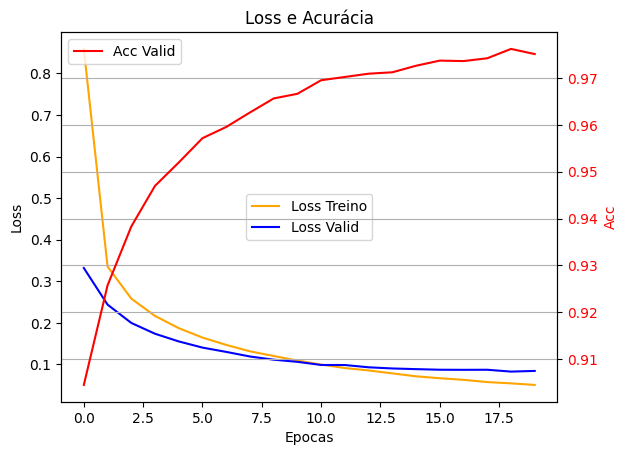

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

# Plotando a primeira série de dados no primeiro eixo (ax1)
ax1.plot(loss_treino, 'orange', label= "Loss Treino")
ax1.plot(loss_valid, 'blue', label= "Loss Valid")
ax1.legend(loc='center')
ax1.set_xlabel("Epocas")
ax1.set_ylabel("Loss", color="black")
ax1.tick_params(axis="y", labelcolor="black")

# Criando o segundo eixo Y que compartilha o mesmo eixo X
ax2 = ax1.twinx()

# Plotando a segunda série de dados no segundo eixo (ax2)
ax2.plot(acc_valid_epoca, 'red', label= "Acc Valid")
ax2.legend()
ax2.set_ylabel("Acc", color="red")
ax2.tick_params(axis="y", labelcolor="red")

# Exibindo o gráfico
plt.title("Loss e Acurácia")
plt.grid()
plt.show()

No geral, as curvas parecem seguir uma tendencia de decaimento. Apesar da curva de validação (curva azul) começar a aumentar um pouco em relação a curva de treino (curva laranja) elas continuam razoavelmente paralelas não sendo um forte indicativo de overfitting.

# Experimento Final: Experimente com o dataset CIFAR-10 uma vez com parâmetros que deram um bom resultado no MNIST. Aproveite a implementação do CIFAR-10 do exercício anterior sua ou de outros colegas.

### Dataset CIFAR10

In [ ]:
import torchvision
import torchvision.transforms as transforms

class CIFAR(torch.utils.data.Dataset):
    def __init__(self, normalize=False, train=False):
        super().__init__()

        #transforma cifar10 em imagem na escala cinza
        self.base_dataset = torchvision.datasets.CIFAR10(root='./data', train=train, download=True, transform=transforms.Grayscale(num_output_channels=1))
        self.normalize = normalize

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        """Retorna (image: np.ndarray, label: int).

        - Converta a imagem do MNIST para np.ndarray float.
        - Se self.normalize, aplique a normalização min-max para [0, 1] (Exercício 3.1)
        """
        image, label = self.base_dataset[idx]
        image = np.array(image, dtype=np.float32)
        if self.normalize:
            image = self.min_max(image)

        image = torch.from_numpy(image).float()
        imagem_1d = image.flatten()

        return imagem_1d, label, image

    def min_max(self, array):
        array = np.array(array)
        return (array - array.min()) / (array.max() - array.min())

### Dataloader CIFAR10

In [ ]:
class DataModuleCIFAR(pl.LightningDataModule):
    def __init__(self, hparams):
        super().__init__()

        # O PyTorch Lightning possui funções para facilitar o uso, log e recuperação de hiperparâmetros
        self.save_hyperparameters(hparams)

    def setup(self, stage=None):
        self.train = CIFAR(train=True, normalize=True)
        self.val = CIFAR(train=False, normalize=True)

    def train_dataloader(self):
        return DataLoader(self.train,
                          batch_size=self.hparams.batch_size,  # note o uso do hiperparâmetro configurável
                          shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val,
                          batch_size=self.hparams.batch_size,
                          shuffle=False)

### Visualização do Dataloader CIFAR10

In [ ]:
datamodule_cifar = DataModuleCIFAR(hyperparameters)
datamodule_cifar.setup()

train_dataloader_cifar = datamodule_cifar.train_dataloader()
val_dataloader_cifar = datamodule_cifar.val_dataloader()

# TODO visualize o batch do dataloader
#visualiza o primeiro batch

primeiro_batch_cifar = next(iter(train_dataloader_cifar))
imagem_linearizada_cifar, label_cifar, imagem_cifar = primeiro_batch_cifar
print(f"Imagem Linearizada: {imagem_linearizada_cifar.shape} --- Label: {label_cifar.shape} --- Imagem Original: {imagem_cifar.shape}")
print("input max:", imagem_linearizada_cifar.abs().max())
print("input min:", imagem_linearizada_cifar.min())

Imagem Linearizada: torch.Size([32, 1024]) --- Label: torch.Size([32]) --- Imagem Original: torch.Size([32, 32, 32])
input max: tensor(1.)
input min: tensor(0.)


Label: 1


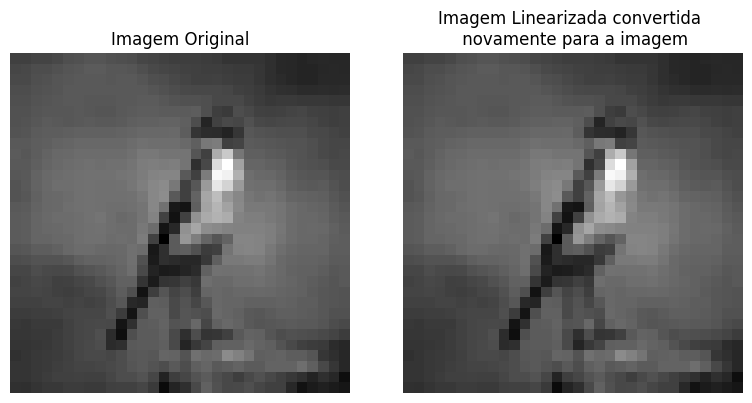

In [ ]:
#Plotar imagens CIFAR
import numpy as np
import matplotlib.pyplot as plt

linear_cifar = imagem_linearizada_cifar[0]
imagem_original_cifar = imagem_cifar[0]
labels_cifar = label[0]

linear_to_image_cifar = linear_cifar.reshape(32, 32)

print(f'Label: {labels_cifar}')

#Plota imagens: original x linearizada convertida para a dimensão 2D
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

ax1.imshow(imagem_original_cifar, cmap='gray')
ax1.set_title('Imagem Original')
ax1.axis('off')

ax2.imshow(linear_to_image_cifar, cmap='gray')
ax2.set_title(f'Imagem Linearizada convertida \n novamente para a imagem')
ax2.axis('off')

plt.tight_layout()
plt.show()

### Loop Treino e Validação

In [ ]:
# TODO
from tqdm import trange
from torchmetrics import Accuracy

epocas = 20
in_features = imagem_linearizada_cifar.shape[1]
n_out = hyperparameters["num_classes"]

#inicializa modelo
model_cifar = MyNeuralNetwork(in_features, n_out, hyperparameters, bias=True)

#inicializar o otimizador
otimizador = torch.optim.Adam(model_cifar.parameters(), lr=hyperparameters["learning_rate"])

#inicializar loss
cross_entropia = MyCrossEntropyLoss(n_out)

#inicializar metrica
acc = Accuracy(task="multiclass", num_classes=n_out)

loss_treino_cifar = []
loss_valid_cifar = []
acc_valid_epoca_cifar = []

for epoca in range(epocas):
  loss_batch_treino = 0
  loss_batch_valid = 0
  acc_soma = 0

  ################### LOOP TREINO #####################
  model_cifar.train()
  with trange(len(train_dataloader_cifar), desc='Loop Treino') as progress_bar:
    for batch_idx, batch in zip(progress_bar, train_dataloader_cifar):
      x, label, _ = batch

      #PASSO 1: forward
      y = model_cifar(x)

      loss = cross_entropia(y, label)
      acc_train = acc(y, label)
      loss_batch_treino = loss + loss_batch_treino
      progress_bar.set_postfix(desc=(f"[Epoca {epoca + 1}] Loss: {loss.item():.4f} Acc: {acc_train:.4f}"))


      #PASSO2: backpropagation
      loss.backward()
      otimizador.step()      #atualiza os pesos do modelo usando o otimizador
      otimizador.zero_grad() #reseta os gradientes

    loss_epoca = loss_batch_treino/len(train_dataloader_cifar) #loss por epoca
    loss_treino_cifar.append(loss_epoca.item())


  ###################### LOOP VALIDAÇÃO ######################
  #não atualiza mais nada
  with trange(len(val_dataloader_cifar), desc='Loop Valid') as progress_bar:
    with torch.no_grad():
      model_cifar.eval()
      for batch_idx, batch in zip(progress_bar, val_dataloader_cifar):
        x, label, _ = batch

        #PASSO 1: forward
        y = model_cifar(x)

        loss = cross_entropia(y, label)
        acc_valid = acc(y, label)
        loss_batch_valid = loss + loss_batch_valid
        acc_soma = acc_valid + acc_soma
        progress_bar.set_postfix(desc=(f"[Epoca {epoca + 1}] Loss: {loss.item():.4f} Acc: {acc_valid:.4f}"))

      loss_epoca_valid = loss_batch_valid/len(val_dataloader_cifar) #loss por epoca
      loss_valid_cifar.append(loss_epoca_valid.item())
      acc_final = acc_soma/len(val_dataloader_cifar)
      acc_valid_epoca_cifar.append(acc_final.item())

Loop Valid: 100%|██████████| 313/313 [00:03<00:00, 84.23it/s, desc=[Epoca 20] Loss: 1.6102 Acc: 0.5000]


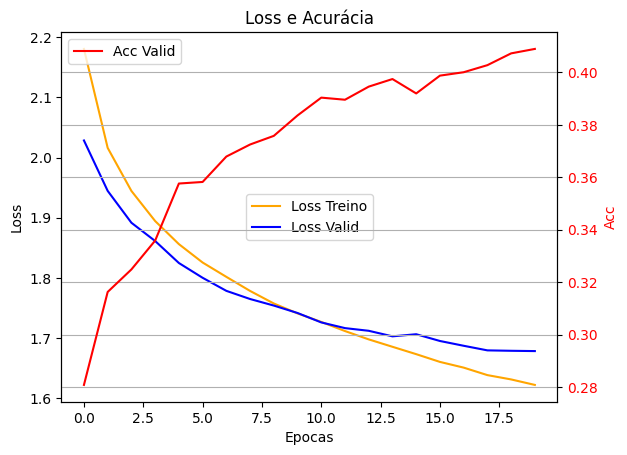

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

# Plotando a primeira série de dados no primeiro eixo (ax1)
ax1.plot(loss_treino_cifar, 'orange', label= "Loss Treino")
ax1.plot(loss_valid_cifar, 'blue', label= "Loss Valid")
ax1.legend(loc='center')
ax1.set_xlabel("Epocas")
ax1.set_ylabel("Loss", color="black")
ax1.tick_params(axis="y", labelcolor="black")

# Criando o segundo eixo Y que compartilha o mesmo eixo X
ax2 = ax1.twinx()

# Plotando a segunda série de dados no segundo eixo (ax2)
ax2.plot(acc_valid_epoca_cifar, 'red', label= "Acc Valid")
ax2.legend()
ax2.set_ylabel("Acc", color="red")
ax2.tick_params(axis="y", labelcolor="red")

# Exibindo o gráfico
plt.title("Loss e Acurácia")
plt.grid()
plt.show()

## Desafios

DESAFIO:

1 - Implemente o loop de treino SGD sem usar otimizadores da biblioteca optimizer (nível médio).

2 - Nível difícil: também sem utilizar .backward().

In [ ]:
class SGD():
  '''
  Função gradiente descendente que substitui o uso das funções
  otimizador.step()
  otimizador.zero_grad()
  '''
  def __init__(self, hparams):
    self.lr = hparams["learning_rate"]

  def __call__(self, model):
    with torch.no_grad():
      for param in model.parameters():
          param -= self.lr * param.grad       #escrever desse jeito permite que a variavel pesos e bias seja de fato alterada
          param.grad.zero_()                  #zera o gradiente


In [ ]:
import copy
import torch

class Backpropagation():
  def __init__(self, delta):
    # Definir um valor pequeno para delta_w e calcular diferenças finitas
    self.delta_w = delta

  def __call__(self, x, model, J, label):

    #Passo 1: salvar parametros originais --> só salva pesos e bias
    parametros_originais = copy.deepcopy(model.state_dict())

    for param in model.parameters():                    #percorre todas as camadas treinaveis

      grad_matriz = torch.zeros_like(param)             #cria tensor com a dimensão da camada para armazenar os gradientes de cada peso ou bias

      for index in range(param.numel()):                #percorre o conteudo de cada camada --> pesos e bias

        model.load_state_dict(parametros_originais)     #carrega pesos do modelo original

        #Passo 2: somar delta_w em w --> soma elemento por elemento
        param.data.view(-1)[index] += self.delta_w

        #Passo 3: fazer a predição --> chamar o modelo
        y_pred1 = model(x)

        #Passo 4: calcular o custo
        J_plus_delta = J(y_pred1, label)

        #Passo 5: repetir passos anteriores para subtrair delta_w em w
        model.load_state_dict(parametros_originais)       #carrega modelo original novamente
        param.data.view(-1)[index] -= self.delta_w        #subtrai delta
        y_pred2 = model(x)                                #calcula a predição
        J_minus_delta = J(y_pred2, label)                 #calcula custo para esse novo peso

        #Passo 6: calcula o gradiente por diferenças finitas e armazena em um tensor
        grad_d = (J_plus_delta - J_minus_delta) / (2 * self.delta_w)
        grad_matriz.view(-1)[index] = grad_d

      #Passo 7: atualizar o grad de camada
      param.grad = grad_matriz

    #Passo 8: restaurar os pesos originais mas mantem os valores de grad calculados
    model.load_state_dict(parametros_originais)


### Mostrando que as funções funcionam

Foi criado um modelo linear com os valores dos pesos controlados para verificar se os resultados obtidos se assemelham com o esperado.

Uma função de custo mais simples, como a MSE, foi utilizada

In [ ]:
class ModeloSimples(torch.nn.Module):

    def __init__(self):
        super().__init__()

        self.weight = torch.nn.Parameter(
            torch.tensor(2.0)
        )

        self.bias = torch.nn.Parameter(
            torch.tensor(1.0)
        )

    def forward(self, x):

        return (x*self.weight) + self.bias

In [ ]:
#inicializa modelo
model = ModeloSimples()

x = torch.tensor(1)       #entrada
label = torch.tensor(5.0) #label

#função de custo
J = torch.nn.MSELoss()

#calcula o gradiente
backpropagation = Backpropagation(delta=1e-3)

In [ ]:
print(" ---- Pesos Iniciais -----")
for name, param in model.named_parameters():
    print(name, "=", param.item())

#faz a predição e calcula a loss
y = model(x)
loss = J(y, label)

print("Predição:", y.item())
print("Loss:", loss.item())

#calcula o gradiente
#nessa etapa ainda os pesos não foram atualizados
backpropagation(x, model, J, label)

print("\n----- Gradientes ------")
for name, param in model.named_parameters():
    print(name, "=", param.grad.item())

print("\n---- Pesos Após o Backpropagation -----")
for name, param in model.named_parameters():
    print(name, "=", param.item())

#chama o otimizador para de fato atualizar os pesos
otimizador = SGD(hyperparameters)
otimizador(model)

print("\n------ Pesos Após SGD -----")
for name, param in model.named_parameters():
    print(name, "=", param.item())

 ---- Pesos Iniciais -----
weight = 2.0
bias = 1.0
Predição: 3.0
Loss: 4.0

----- Gradientes ------
weight = -3.9997098445892334
bias = -3.9997098445892334

---- Pesos Após o Backpropagation -----
weight = 2.0
bias = 1.0

------ Pesos Após SGD -----
weight = 2.0004000663757324
bias = 1.0003999471664429


### MNIST: Usando somente a função SGD e usando o backpropagation do pytorch

A função backpropagation por diferenças finitas é muito demorado (O(N²)). Assim, para entradas muito grandes como o MNIST (784 elementos para cada imagem) o algoritimo fica muito lento, não sendo possível completar o treinamento. Assim, o teste anterior comprova o funcionamento da função backpropagation para uma entrada extremamente simples. Abaixo, o treino do MNIST é feito usando a função SGD implementada e o backpropagation do pytorch.

In [ ]:
# TODO
from tqdm import trange
from torchmetrics import Accuracy

epocas = 200
in_features = imagem_linearizada.shape[1]
n_out = hyperparameters["num_classes"]

#inicializa modelo
model = MyNeuralNetwork(
    in_features=in_features,
    n_out=n_out,
    hparams=hyperparameters,
    bias=True
)

#inicializar o otimizador
otimizador = SGD(hyperparameters)
#otimizador = torch.optim.Adam(model.parameters(), lr=hyperparameters["learning_rate"])

#inicializar loss
cross_entropia = MyCrossEntropyLoss(n_out)

#inicializar metrica
acc = Accuracy(task="multiclass", num_classes=n_out)

loss_treino = []
loss_valid = []
acc_valid_epoca = []

for epoca in range(epocas):
  loss_batch_treino = 0
  loss_batch_valid = 0
  acc_soma = 0

  ################### LOOP TREINO #####################
  model.train()
  with trange(len(train_dataloader), desc='Loop Treino') as progress_bar:
    for batch_idx, batch in zip(progress_bar, train_dataloader):
      x, label, _ = batch

      #PASSO 1: forward
      y = model(x)

      loss = cross_entropia(y, label)
      acc_train = acc(y, label)
      loss_batch_treino = loss + loss_batch_treino
      progress_bar.set_postfix(desc=(f"[Epoca {epoca + 1}] Loss: {loss.item():.4f} Acc: {acc_train:.4f}"))


      #PASSO2: backpropagation
      loss.backward()

      #atualização dos pesos + zerar gardientes
      otimizador(model)
      #otimizador.step()
      #otimizador.zero_grad()

    loss_epoca = loss_batch_treino/len(train_dataloader) #loss por epoca
    loss_treino.append(loss_epoca.item())


  ###################### LOOP VALIDAÇÃO ######################
  #não atualiza mais nada
  with trange(len(val_dataloader), desc='Loop Valid') as progress_bar:
    with torch.no_grad():
      model.eval()
      for batch_idx, batch in zip(progress_bar, val_dataloader):
        x, label, _ = batch

        #PASSO 1: forward
        y = model(x)

        loss = cross_entropia(y, label)
        acc_valid = acc(y, label)
        loss_batch_valid = loss + loss_batch_valid
        acc_soma = acc_valid + acc_soma
        progress_bar.set_postfix(desc=(f"[Epoca {epoca + 1}] Loss: {loss.item():.4f} Acc: {acc_valid:.4f}"))

      loss_epoca_valid = loss_batch_valid/len(val_dataloader) #loss por epoca
      loss_valid.append(loss_epoca_valid.item())
      acc_final = acc_soma/len(val_dataloader)
      acc_valid_epoca.append(acc_final.item())

Loop Valid: 100%|██████████| 313/313 [00:02<00:00, 111.28it/s, desc=[Epoca 200] Loss: 0.1301 Acc: 0.9375]


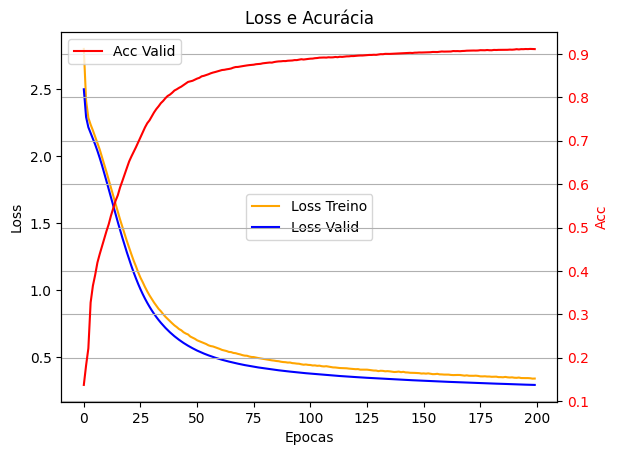

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

# Plotando a primeira série de dados no primeiro eixo (ax1)
ax1.plot(loss_treino, 'orange', label= "Loss Treino")
ax1.plot(loss_valid, 'blue', label= "Loss Valid")
ax1.legend(loc='center')
ax1.set_xlabel("Epocas")
ax1.set_ylabel("Loss", color="black")
ax1.tick_params(axis="y", labelcolor="black")

# Criando o segundo eixo Y que compartilha o mesmo eixo X
ax2 = ax1.twinx()

# Plotando a segunda série de dados no segundo eixo (ax2)
ax2.plot(acc_valid_epoca, 'red', label= "Acc Valid")
ax2.legend()
ax2.set_ylabel("Acc", color="red")
ax2.tick_params(axis="y", labelcolor="red")

# Exibindo o gráfico
plt.title("Loss e Acurácia")
plt.grid()
plt.show()

É interessante observar que usando o otimizador SGD implementado para obter acurácia parecida em relação ao otimizador ADAM do pytorch usando anteriormente foi necessário aumentar em 10x a quantidade de épocas.